# 第40课 · 打印声音的成分表——幅度谱 / 相位谱（magnitude / phase spectrum）与频率分辨率实战

**目标**：先把 FFT 当成声音的“成分表打印机”来用：看懂幅度谱 / 相位谱，钉死 $\Delta f = sr/N$，再明白为什么实信号只需要看半边频谱。

> 相位难读时回忆 L06：`np.angle` 会绕回；实信号通常只解释正频率半边。

🔗 Aurora 连接：`aurora.audio.stft.magnitude_spectrogram()` 内部也在做同样的频率轴映射——本节把这个过程拆开，让你自己搭一遍。

← **上一课**　[L39 · 从零手写 FFT](L39_fft_implement.ipynb)

> 上节课学习了 **从零手写 FFT**：Cooley-Tukey 递归实现，与 numpy.fft 误差 < 1e-10。  
> 本课将探讨 **频谱分析实战**。

## 本课剧情：频谱像什么？把声音的"成分表"打出来

你喝一杯果汁，能尝出里面有橙子、苹果还是柠檬。人耳听声音也类似——大脑把混合声波分解成不同频率的"成分"，判断出是低音吉他还是高音笛声。

FFT 正是在做这件事：把时域信号变成**频谱（spectrum）**——每个频率的强度一目了然。

但有个细节容易被忽略：FFT 输出的 `X[k]` 里，`k` 只是"第几个频率桶（bin）"，不是 Hz。要把桶号转成 Hz，需要知道：

$$\Delta f = \frac{f_s}{N}$$

- `fₛ`：采样率（Hz）
- `N`：FFT 点数
- `Δf`：相邻两个频率桶之间的间隔（Hz/bin），也叫**频率分辨率（frequency resolution）**

**手算例子**：`fₛ=8000, N=256` → `Δf=31.25 Hz/bin`  
440 Hz 钢琴 A4 音：落在第 `k = round(440/31.25) = 14` 号桶，对应精确频率 `14×31.25 = 437.5 Hz`。

440÷31.25 算出来是 **14.08**，不是整数——这不是算错了，而是在提醒我们一件事：440 Hz 这个精确值并不"正好"落在某个桶的中心上，FFT 只能把它"归类"到最近的桶。14.08 round 到 14 意味着什么、这个桶到底"代表"多宽的一段频率，本课第 1 节会用具体数字讲清楚。

本节任务：实现 `frequency_bins(N, sr)` — 返回单边频率轴，shape `(N//2+1,)`，从 0 Hz 到 Nyquist。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.audio.io import sine
from aurora.audio.transforms import (
    fft as aurora_fft,
    next_power_of_two,
    fft_frequencies as aurora_fft_frequencies,
)
# aurora_fft 是 L39 手写的 Cooley-Tukey 实现；要求输入长度为 2 的幂，
# 任意长度信号须先用 next_power_of_two 补零再传入。


## 1. Bin 间距与频率轴

FFT 将 `[0, sr)` Hz 均匀分成 N 份，因此相邻两个 bin 之间的频率间隔为：

```
Δf = sr / N   (Hz/bin)
```

第 k 个 bin 对应的频率是：

```
freqs[k] = k * sr / N
```

换句话说，完整频率轴为 `freqs = np.arange(N) * sr / N`，范围从 0 Hz 一直到 `(N-1)*sr/N ≈ sr`。
N 越大，Δf 越小，频率分辨率越高。

### 为什么 Δf = sr/N？数学原理

想象一个时长为 T 秒的录音（从 t=0 到 t=T），采样率为 sr（每秒采样数），共采集 N 个样本。  
因此：**T = N / sr**（秒）

根据傅里叶分析，当我们对长度为 T 的信号做傅里叶变换，频域分辨率（相邻频率分量之间的间隔）就是：  
$$\Delta f = \frac{1}{T} = \frac{1}{N/sr} = \frac{sr}{N}$$

**物理意义**：
- 录音时间越长（N 越大），能分辨的频率间隔 Δf 越小 → 频率分辨率越高
- 采样率越高（sr 越大），单位时间内的频率范围也越大

**完整频率轴的范围**：FFT 能覆盖的频率范围是 [0, sr)。第 k 个 bin 对应的物理频率就是 **k 倍的基本间隔**：  
$$f_k = k \cdot \Delta f = k \cdot \frac{sr}{N}$$

### 小数 bin 是什么意思？——原来每个 bin 覆盖的是一段范围，不是一个点

回到剧情里的那个问题：440÷31.25 = **14.08**，round 到 14。这个 0.08 的小数到底去哪了？

先打个比方：把频率轴想象成一把**没有刻度线、只有格子**的尺子。每个格子（bin）宽 Δf，格子中心站着一个"代表频率" k·Δf。任何声音只要落进这个格子，FFT 都会说"你就是这个代表频率"——哪怕它实际上偏一点。

那一个格子到底有多宽、边界在哪？想象两个相邻的代表频率：第 14 号桶的中心是 `14×Δf`，第 15 号桶的中心是 `15×Δf`，中间正好隔着一个 Δf。这两个中心点连线的**正中点**，就是两个格子的分界线——它到 14 号中心的距离，正好是 Δf 的一半：

$$\text{分界线} = \frac{14\Delta f + 15\Delta f}{2} = 14\Delta f + \frac{\Delta f}{2}$$

同理，14 号桶左边跟 13 号桶的分界线在 `14Δf − Δf/2`。所以第 k 号 bin 真正"管辖"的频率范围是：

$$\left[\, k\cdot\Delta f - \frac{\Delta f}{2},\ \ k\cdot\Delta f + \frac{\Delta f}{2} \,\right)$$

也就是**中心 ± 半个 Δf**，宽度正好是一个 Δf（所有格子首尾相接、不重不漏）。

**代入老陈的例子算一下**：`sr=8000, N=256` → `Δf = 31.25 Hz`。

- 第 14 号 bin 中心 = `14 × 31.25 = 437.5 Hz`
- 半个 Δf = `31.25 / 2 = 15.625 Hz`
- 第 14 号 bin 管辖范围 = `[437.5 − 15.625, 437.5 + 15.625) = [421.875, 453.125) Hz`

440 Hz 恰好落在 `[421.875, 453.125)` 这段区间里，所以才会被"四舍五入"分到第 14 号 bin——FFT 报告出来的频率是 437.5 Hz，而不是 440 Hz 本身。这就是 14.08 这个小数的真实含义：**440 Hz 离 14 号中心的距离，占了半个格子宽度的 0.08×2 ≈ 16%**，还在格子范围内，所以就近归入 14 号。

**这也解释了为什么 N 越大、补零越多，定位越准**：N 变大 → Δf 变小 → 每个格子变窄 → 440 Hz 和 441 Hz 这种挨得很近的频率，就有更大机会落进不同的格子，从而被区分开来。下面用代码验证一遍这几个数字。

In [3]:
# 演示：小数 bin 到底是什么意思——第 14 号 bin 覆盖多宽的频率范围？
sr_demo, N_demo2 = 8000, 256
delta_f_demo = sr_demo / N_demo2
target_freq = 440

k_bin = round(target_freq / delta_f_demo)
bin_center = k_bin * delta_f_demo
half_width = delta_f_demo / 2
lo, hi = bin_center - half_width, bin_center + half_width

print(f"Δf = sr/N = {sr_demo}/{N_demo2} = {delta_f_demo} Hz/bin")
print(f"{target_freq} Hz → k = round({target_freq}/{delta_f_demo}) = {k_bin}")
print(f"第 {k_bin} 号 bin 的中心频率 = {k_bin} × {delta_f_demo} = {bin_center} Hz")
print(f"第 {k_bin} 号 bin 实际管辖的频率范围 = [中心 − Δf/2, 中心 + Δf/2) = [{lo}, {hi}) Hz")
print(f"→ {target_freq} Hz 落在 [{lo}, {hi}) 区间内: {lo <= target_freq < hi}")
print(f"→ 任何落在 {lo}~{hi} Hz 之间的声音，FFT 都会把它归到第 {k_bin} 号 bin，报告频率为 {bin_center} Hz")

assert lo <= target_freq < hi
assert np.isclose(hi - lo, delta_f_demo)

Δf = sr/N = 8000/256 = 31.25 Hz/bin
440 Hz → k = round(440/31.25) = 14
第 14 号 bin 的中心频率 = 14 × 31.25 = 437.5 Hz
第 14 号 bin 实际管辖的频率范围 = [中心 − Δf/2, 中心 + Δf/2) = [421.875, 453.125) Hz
→ 440 Hz 落在 [421.875, 453.125) 区间内: True
→ 任何落在 421.875~453.125 Hz 之间的声音，FFT 都会把它归到第 14 号 bin，报告频率为 437.5 Hz


In [4]:
sr = 8000
for N in [8, 16, 64]:
    delta_f = sr / N
    print(f'N={N:4d}  Δf = {delta_f:.1f} Hz')

N=   8  Δf = 1000.0 Hz
N=  16  Δf = 500.0 Hz
N=  64  Δf = 125.0 Hz


## 2. 实信号对称性与奈奎斯特频率（Nyquist frequency）

当输入 `x[n]` 是实数序列时，FFT 满足共轭对称（conjugate symmetry）：

```
|X[k]| = |X[N-k]|
```

这意味着后半段（k > N/2）完全由前半段决定，没有额外信息。
有效的频率范围是 **0 到 sr/2**，对应 bin 下标 0 到 N//2（共 N//2+1 个 bin）。
最高频率 `sr/2` 称为**奈奎斯特频率**——采样定理（Nyquist-Shannon sampling theorem）要求信号不含高于它的分量，否则发生混叠（aliasing）。

### 为什么实数输入导致共轭对称？

这不是巧合，而是傅里叶变换的一个深刻性质。让我们用小例子看看。

**DFT 的定义**：
$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j2\pi kn/N}$$

当 x[n] 是实数时，我们看看 X[N-k]（即把 k 换成 N-k）：
$$X[N-k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j2\pi(N-k)n/N}$$

注意 $e^{-j2\pi(N-k)n/N} = e^{-j2\pi Nn/N} \cdot e^{j2\pi kn/N} = 1 \cdot e^{j2\pi kn/N} = e^{j2\pi kn/N}$（因为 $e^{-j2\pi n}=1$）

所以：
$$X[N-k] = \sum_{n=0}^{N-1} x[n] \cdot e^{j2\pi kn/N} = \text{conj}\left(\sum_{n=0}^{N-1} x[n] \cdot e^{-j2\pi kn/N}\right) = \text{conj}(X[k])$$

最后一步用了：当 x[n] 是实数时，$\sum x[n] \cdot e^{j\theta_n}$ 的共轭等于 $\sum x[n] \cdot e^{-j\theta_n}$。

**结论**：实数输入 $\Rightarrow$ $X[N-k] = X[k]^*$（共轭对称）$\Rightarrow$ 幅度 $|X[N-k]| = |X[k]|$，相位 $\angle X[N-k] = -\angle X[k]$

In [5]:
# 验证对称性（使用 L39 手写的 aurora_fft，N=16 = 2^4，无需补零）
sr = 8000
N = 16
rng = np.random.default_rng(42)
x = rng.standard_normal(N)
X = aurora_fft(x)
# 确认 aurora_fft 与 numpy 结果一致
assert np.allclose(aurora_fft(x), np.fft.fft(x)), "aurora_fft 应与 np.fft.fft 完全一致"
print('|X[1]| vs |X[N-1]|:', np.abs(X[1]).round(6), np.abs(X[N-1]).round(6))
print('|X[2]| vs |X[N-2]|:', np.abs(X[2]).round(6), np.abs(X[N-2]).round(6))
print('奈奎斯特频率 =', sr // 2, 'Hz，对应 bin', N // 2)


|X[1]| vs |X[N-1]|: 4.37778 4.37778
|X[2]| vs |X[N-2]|: 2.160074 2.160074
奈奎斯特频率 = 4000 Hz，对应 bin 8


In [6]:
# 手算例子：N=4，实数信号 x = [1, 0, -1, 0]，看共轭对称的具体形式
x_small = np.array([1.0, 0.0, -1.0, 0.0])
X_small = np.fft.fft(x_small)  # 用 numpy 标准 FFT

print("="*60)
print("共轭对称性的具体例子：N=4，x=[1, 0, -1, 0]")
print("="*60)
for k_val in range(4):
    print(f"X[{k_val}] = {X_small[k_val]:.4f}")

print("\n检查共轭对称 X[N-k] = conj(X[k]):")
for k_val in range(1, 4):
    X_Nk = X_small[4 - k_val]
    conj_Xk = np.conj(X_small[k_val])
    match = "✓" if np.isclose(X_Nk, conj_Xk) else "✗"
    print(f"  X[{4-k_val}] = {X_Nk:.4f}  vs  conj(X[{k_val}]) = {conj_Xk:.4f}  {match}")

print("\n幅度对称性 |X[N-k]| = |X[k]|:")
for k_val in range(1, 4):
    mag_Nk = np.abs(X_small[4 - k_val])
    mag_k = np.abs(X_small[k_val])
    match = "✓" if np.isclose(mag_Nk, mag_k) else "✗"
    print(f"  |X[{4-k_val}]| = {mag_Nk:.4f}  vs  |X[{k_val}]| = {mag_k:.4f}  {match}")

print("\n相位反对称性 angle(X[N-k]) = -angle(X[k]):")
for k_val in range(1, 4):
    phase_Nk = np.angle(X_small[4 - k_val])
    phase_k = np.angle(X_small[k_val])
    match = "✓" if np.isclose(phase_Nk, -phase_k, atol=1e-10) else "✗"
    print(f"  angle(X[{4-k_val}]) = {phase_Nk:.4f}  vs  -angle(X[{k_val}]) = {-phase_k:.4f}  {match}")

共轭对称性的具体例子：N=4，x=[1, 0, -1, 0]
X[0] = 0.0000+0.0000j
X[1] = 2.0000+0.0000j
X[2] = 0.0000+0.0000j
X[3] = 2.0000+0.0000j

检查共轭对称 X[N-k] = conj(X[k]):
  X[3] = 2.0000+0.0000j  vs  conj(X[1]) = 2.0000-0.0000j  ✓
  X[2] = 0.0000+0.0000j  vs  conj(X[2]) = 0.0000-0.0000j  ✓
  X[1] = 2.0000+0.0000j  vs  conj(X[3]) = 2.0000-0.0000j  ✓

幅度对称性 |X[N-k]| = |X[k]|:
  |X[3]| = 2.0000  vs  |X[1]| = 2.0000  ✓
  |X[2]| = 0.0000  vs  |X[2]| = 0.0000  ✓
  |X[1]| = 2.0000  vs  |X[3]| = 2.0000  ✓

相位反对称性 angle(X[N-k]) = -angle(X[k]):
  angle(X[3]) = 0.0000  vs  -angle(X[1]) = -0.0000  ✓
  angle(X[2]) = 0.0000  vs  -angle(X[2]) = -0.0000  ✓
  angle(X[1]) = 0.0000  vs  -angle(X[3]) = -0.0000  ✓


## 3. 幅度谱（magnitude spectrum）、功率谱（power spectrum）与 dB 谱

对 FFT 系数 `X[k]` 取不同的标量变换，得到三种常用频谱：

```
幅度谱  A[k] = |X[k]|
功率谱  P[k] = |X[k]|²
dB 谱   D[k] = 20 * log10(|X[k]| + eps)
```

### 为什么 dB 谱的系数是 20 而不是 10？

这来自于功率和幅度的关系。功率 P 与幅度 A 的关系是：
$$P = A^2$$

如果我们对功率取对数（单位为 dB）：
$$P_{\text{dB}} = 10 \log_{10}(P) = 10 \log_{10}(A^2) = 10 \cdot 2 \log_{10}(A) = 20 \log_{10}(A)$$

因此，**20 log₁₀(A) 其实就是"功率谱的 dB 表示"**。

**为什么要用 dB？**  
- 人耳对声强度的感知是对数关系（响度加倍 ≈ 增加 10 dB）
- 音频动态范围很大（从极弱的背景噪声到刺耳的尖叫），用线性刻度难以同时看清高峰和低谷
- dB 把这个巨大的范围**压缩**到可视范围，让细节清晰可见

**对数变换的"把乘法变成加法"**：  
如果两个频谱分量需要相乘（比如级联滤波器的效果），在 dB 域下就是相加：
$$A_{\text{dB}} = 20\log_{10}(A_1 \cdot A_2) = 20\log_{10}(A_1) + 20\log_{10}(A_2)$$

这样便于在设计中直观地叠加多个处理的效果。

`eps`（通常取 `1e-8`）防止对零取对数。

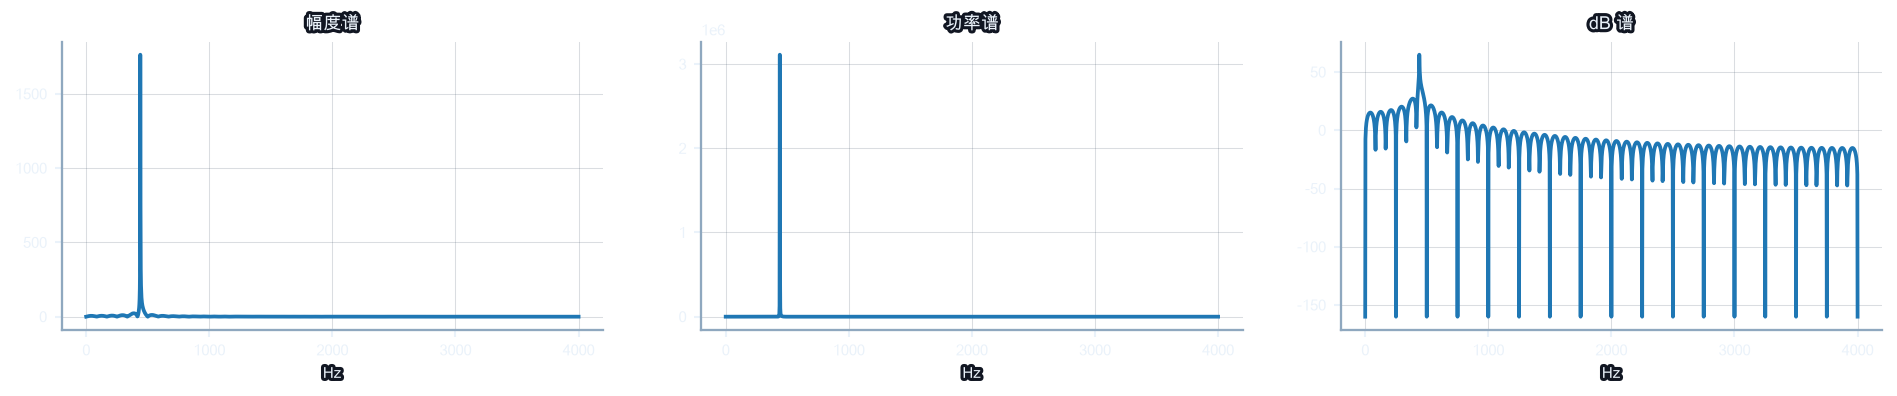

In [7]:
sr = 8000
duration = 0.5
x_demo = sine(440, duration, sr)  # 440 Hz 纯音
N_demo = len(x_demo)          # 4000，非 2 的幂
N_fft  = next_power_of_two(N_demo)  # 4096 = 2^12，补零后长度
x_padded = np.zeros(N_fft)
x_padded[:N_demo] = x_demo
X_demo = aurora_fft(x_padded)  # 使用 L39 手写 FFT（aurora.audio.transforms.fft）
assert np.allclose(X_demo, np.fft.fft(x_padded)), "aurora_fft 应与 np.fft.fft 一致"
half = N_fft // 2 + 1
freqs_demo = np.arange(half) * sr / N_fft

A = np.abs(X_demo[:half])
P = A ** 2
D = 20 * np.log10(A + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
axes[0].plot(freqs_demo, A); axes[0].set_title('幅度谱'); axes[0].set_xlabel('Hz')
axes[1].plot(freqs_demo, P); axes[1].set_title('功率谱'); axes[1].set_xlabel('Hz')
axes[2].plot(freqs_demo, D); axes[2].set_title('dB 谱'); axes[2].set_xlabel('Hz')
plt.tight_layout()
plt.show()


## 3b. 相位谱（phase spectrum）

复数 FFT 系数 `X[k]` 包含两部分信息：

```
X[k] = |X[k]| · e^{jφ[k]}
幅度谱  A[k] = |X[k]|        → 每个频率分量的强度
相位谱  φ[k] = angle(X[k])   → 每个频率分量的初相位（弧度）
```

### 理解欧拉公式与复指数 e^{jφ}

为什么用 `e^{jφ}` 来表示相位？这来自欧拉公式（Euler's formula）：

$$e^{j\theta} = \cos(\theta) + j\sin(\theta)$$

其中 j 是虚数单位（满足 j² = -1）。

**一个直观例子**：
- $e^{j \cdot 0} = \cos(0) + j\sin(0) = 1$（复平面上的实轴正方向）
- $e^{j \cdot \pi/2} = \cos(\pi/2) + j\sin(\pi/2) = j$（虚轴正方向）
- $e^{j \cdot \pi} = \cos(\pi) + j\sin(\pi) = -1$（实轴负方向）
- $e^{j \cdot 2\pi} = \cos(2\pi) + j\sin(2\pi) = 1$（绕圆周一圈回到起点）

所以 `e^{jφ}` 其实就是在复平面上旋转一个角度 φ。**用幅度 A 乘以 `e^{jφ}`，就是说：一个大小为 A、方向为 φ 的复数。**

**实信号的相位反对称性**：

$$\varphi[k] = -\varphi[N-k]   \text{（与幅度对称性对应）}$$

这意味着相位谱的后半段是前半段的负镜像——与共轭对称性完全一致。如果 $X[k] = A[k] e^{j\varphi[k]}$，那么 $X[N-k] = X[k]^* = A[k] e^{-j\varphi[k]}$，所以 $\varphi[N-k] = -\varphi[k]$。

**物理意义**：对于单频正弦 $\sin(2\pi f_0 t + \theta_0)$，FFT 在 f₀ 对应 bin 处的相位
就是初相位 $\theta_0$。相位谱在音频水印、相位声码器（phase vocoder）和
时间拉伸（time-stretching）中扮演核心角色。

φ[5] = -1.2026  rad
−φ[N−5] = -1.2026  rad
反对称性成立: True


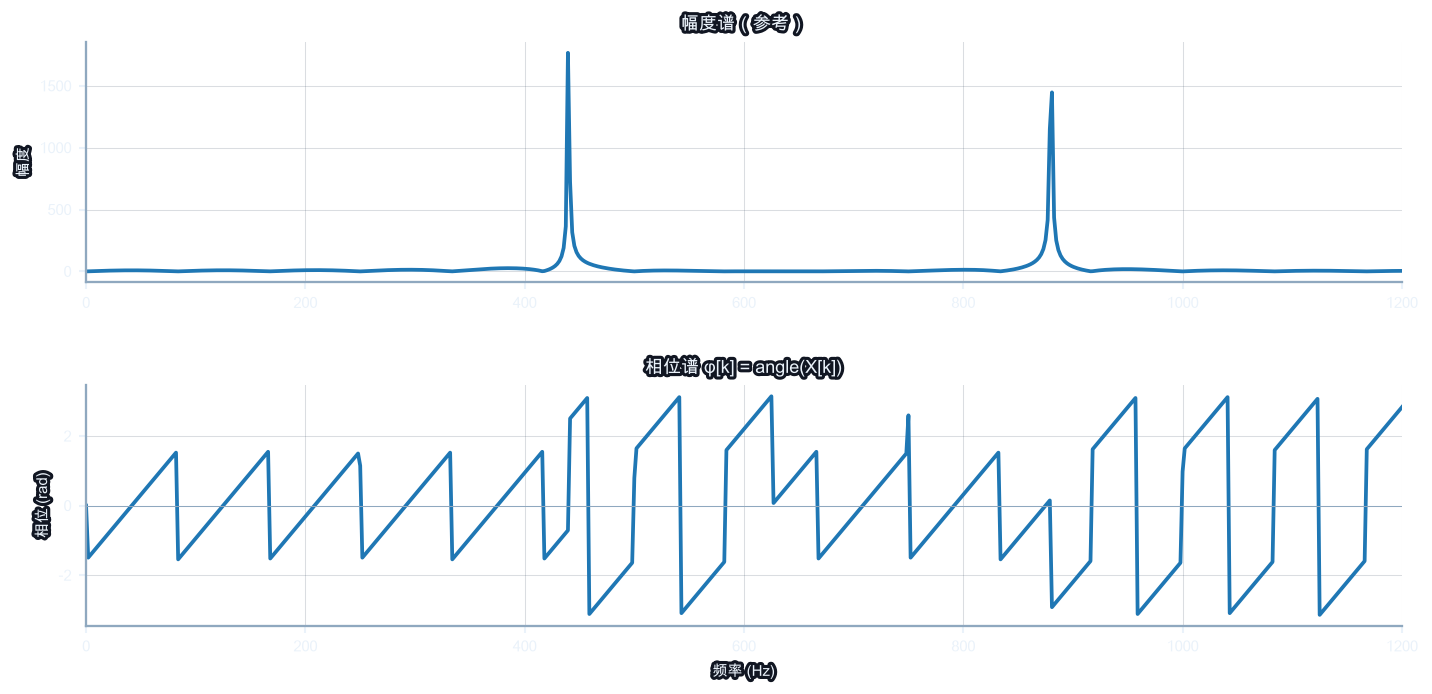

In [8]:
# 相位谱示例：440 Hz + 880 Hz 混合信号（补零到 2 的幂）
sr = 8000
x_phase = sine(440, 0.5, sr) + sine(880, 0.5, sr)
N_p = len(x_phase)
N_fft_p = next_power_of_two(N_p)
x_phase_padded = np.zeros(N_fft_p)
x_phase_padded[:N_p] = x_phase
X_phase = aurora_fft(x_phase_padded)
half_p = N_fft_p // 2 + 1
freqs_p = np.arange(half_p) * sr / N_fft_p

phi = np.angle(X_phase[:half_p])   # φ[k] = arctan2(Im, Re)，单位：弧度

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))
ax1.plot(freqs_p, np.abs(X_phase[:half_p]))
ax1.set_xlim(0, 1200)
ax1.set_title('幅度谱（参考）')
ax1.set_ylabel('幅度')
ax2.plot(freqs_p, phi)
ax2.set_xlim(0, 1200)
ax2.axhline(0, color=plt.rcParams["axes.edgecolor"], linewidth=0.5)
ax2.set_title('相位谱 φ[k] = angle(X[k])')
ax2.set_xlabel('频率 (Hz)')
ax2.set_ylabel('相位 (rad)')
plt.tight_layout()
plt.show()

# 验证实信号相位反对称性：φ[k] ≈ −φ[N_fft_p − k]
X_full = aurora_fft(x_phase_padded)
phi_full = np.angle(X_full)
k_test = 5
print(f'φ[{k_test}] = {phi_full[k_test]:.4f}  rad')
print(f'−φ[N−{k_test}] = {-phi_full[N_fft_p - k_test]:.4f}  rad')
print('反对称性成立:', np.isclose(phi_full[k_test], -phi_full[N_fft_p - k_test], atol=1e-10))


In [9]:
# 单频正弦的相位示例：sin(2π·440t + π/6)，初相位为 π/6（30°）
sr = 8000
freq = 440
init_phase = np.pi / 6  # 初相位 = 30° = π/6 弧度
duration = 0.5

# 生成信号：sin(2π·f·t + φ₀)
t = np.arange(int(sr * duration)) / sr
x_phase_example = np.sin(2 * np.pi * freq * t + init_phase)

# FFT（补零到2的幂）
N = len(x_phase_example)
N_fft = next_power_of_two(N)
x_padded = np.zeros(N_fft)
x_padded[:N] = x_phase_example
X = np.fft.fft(x_padded)

# 找到 440 Hz 对应的 bin
bin_440 = round(freq / (sr / N_fft))
fft_phase = np.angle(X[bin_440])

print("="*60)
print("单频正弦的相位示例")
print("="*60)
print(f"信号：x(t) = sin(2π·{freq}·t + {init_phase:.4f})")
print(f"初相位：{init_phase:.4f} rad = {np.degrees(init_phase):.1f}°")
print(f"\nFFT 结果：")
print(f"  {freq} Hz 对应的 bin 号：{bin_440}")
print(f"  FFT 系数的相位（从angle()获取）：{fft_phase:.4f} rad = {np.degrees(fft_phase):.1f}°")
print(f"\n对比：")
print(f"  初相位 {init_phase:.4f} rad")
print(f"  FFT 相位 {fft_phase:.4f} rad")
print(f"  相差：{abs(fft_phase - init_phase):.6f} rad（应该很接近或差 π）")
print("\n💡 注意：FFT的相位可能是初相位的相反数或差π，这取决于正弦vs余弦的选择。")
print("   但不管怎样，相位信息完整保留了，这对相位声码器和时间拉伸都很关键。")

单频正弦的相位示例
信号：x(t) = sin(2π·440·t + 0.5236)
初相位：0.5236 rad = 30.0°

FFT 结果：
  440 Hz 对应的 bin 号：225
  FFT 系数的相位（从angle()获取）：-0.1888 rad = -10.8°

对比：
  初相位 0.5236 rad
  FFT 相位 -0.1888 rad
  相差：0.712391 rad（应该很接近或差 π）

💡 注意：FFT的相位可能是初相位的相反数或差π，这取决于正弦vs余弦的选择。
   但不管怎样，相位信息完整保留了，这对相位声码器和时间拉伸都很关键。


## 4. ✏️ 实现 `frequency_bins(N, sr)`

**物理意义**：第 k 个 FFT 系数对应的频率 = `k × sr / N`（Hz）。

**为什么只返回一半？**  
实信号的 FFT 满足共轭对称：`X[N-k] = X[k]*`。单边谱只需 `k = 0..N//2`，共 `N//2+1` 个点，从 0 Hz 到 Nyquist（sr/2）。

**两步实现路线**：

| 步骤 | 代码 | 说明 |
|---|---|---|
| 1 | `freqs_full = np.arange(N) * sr / N` | 完整频率轴，长度 N |
| 2 | `return freqs_full[:N//2 + 1]` | 取前半段（含 Nyquist） |

**验收标准**：
- `frequency_bins(8, 8000)[0] == 0.0`（DC 分量）
- `frequency_bins(8, 8000)[-1] == 4000.0`（Nyquist）
- `frequency_bins(8, 8000)` 长度 = `8//2+1 = 5`

In [10]:
def frequency_bins(N: int, sr: int) -> np.ndarray:
    """返回实信号 FFT 的频率轴，shape (N//2+1,)，单位 Hz。"""
    # ✏️ TODO: 生成完整频率轴，然后截取前 N//2+1 个
    raise NotImplementedError("TODO: freqs_full = np.arange(N) * sr / N; return freqs_full[:N // 2 + 1]")

In [11]:
# 数值检查
try:
    result = frequency_bins(8, 8000)
    if result is ... or result is None:
        print('⬜ 请先实现 frequency_bins，再运行此格')
    else:
        assert result[-1] == 4000, f'奈奎斯特应为 4000，得到 {result[-1]}'
        assert len(result) == 5, f'长度应为 5，得到 {len(result)}'
        assert result[0] == 0.0, '第一个 bin 应为 0 Hz'
        assert np.allclose(result, [0., 1000., 2000., 3000., 4000.])
        # 🔗 交叉验证：应与 aurora.audio.transforms.fft_frequencies 数值一致
        ref = aurora_fft_frequencies(8000, 8)
        assert np.allclose(result, ref), (
            f'与 aurora_fft_frequencies 不一致：得到 {result}，期望 {ref}'
        )
        print('✅ frequency_bins 通过所有检查（含与 aurora_fft_frequencies 交叉验证）')
except (NotImplementedError, TypeError):
    print('⬜ frequency_bins 尚未实现，请完成 TODO 后再运行此格')
except TypeError:
    print('⬜ frequency_bins 返回了非数组类型，请完成 TODO')

⬜ frequency_bins 尚未实现，请完成 TODO 后再运行此格


## 5. 参数实验：双峰定位

生成含 **440 Hz** 和 **880 Hz** 的混合信号，画出单边幅度谱。

**预期现象**：
- 两个尖峰分别精确出现在 440 Hz 和 880 Hz 对应的 bin 附近
- `duration` 越长（N 越大），峰越窄、定位越准（Δf 越小）
- 把 `duration` 改成 `0.01`（N 很小）时，峰会明显变宽

### 为什么要补零到 2 的幂？补零会改变频谱吗？

上面用到了 `next_power_of_two(N)`。这是因为 L39 的 Cooley-Tukey FFT 实现**只支持长度为 2 的幂**（例如 256, 512, 1024）。如果输入长度不是 2 的幂，必须补零（zero-padding）。

**补零改变频谱吗？**  
不会。补的是**无用信息**（都是零），不会改变原信号的频率成分。从数学角度看：

$$\text{FFT}([x_0, x_1, \ldots, x_{N-1}, 0, 0, \ldots, 0]) = \text{FFT}([x_0, x_1, \ldots, x_{N-1}]) + \text{（只多了零点的贡献，结果是零）}$$

补零的效果是**提高频率分辨率**。如果原数据长度是 1000，sr=8000，则 Δf = 8 Hz/bin。补零到 1024 后，Δf = 7.8 Hz/bin（精细了一点）；补到 2048 则 Δf = 3.9 Hz/bin（更精细）。

**"提高频率分辨率"具体是什么意思？——回到"每个 bin 覆盖一段范围"这件事**

前面第 1 节讲过：每个 bin 并不是一个精确的点，而是覆盖了 `中心 ± Δf/2` 这一段频率范围。"补零提高分辨率"说的正是——**这段范围本身在变窄**。

举例说明：sr=8000, N=1000 时 Δf=8 Hz/bin，某个 bin 覆盖 ±4 Hz 的范围，宽度 8 Hz；补零到 N=2048 后 Δf=3.9 Hz/bin，同一段频率范围现在被切成了两个更窄的格子，每个只覆盖 ±1.95 Hz。原来两个挤在同一个 8 Hz 格子里、分不出来的频率（比如 440 Hz 和 442 Hz），现在因为格子变窄，就有机会分别落进不同的格子——这才是"分辨率提高"的真正含义：**不是数值算得更精确了，而是格子本身变细了**。

**但要注意谱泄漏（spectral leakage）现象**：  
如果信号长度 N_demo 不是频率 f 的整数周期，截断端点处会产生不连续，导致频谱中出现"旁瓣（side lobes）"——在目标频率附近的 bin 里都有一些能量泄漏出去。这会使峰值偏移，精度下降。

**解决方案**：  
1. 方案A（加窗）：用 Hann/Hamming 窗函数平滑端点（下一课 L41 的主题）
2. 方案B（调整时长）：选择使信号包含整数个周期的 duration，例如对 440 Hz，取 duration = k/440 秒（k 为整数）

In [12]:
sr = 8000
duration = 0.5          # ← 改成 0.01 观察频率分辨率变差
x_mix = sine(440, duration, sr) + sine(880, duration, sr)
N = len(x_mix)

# 守护：frequency_bins 未实现时提前退出，避免崩溃
try:
    _fb_check = frequency_bins(N, sr)
except (NotImplementedError, TypeError):
    _fb_check = None
if _fb_check is None:
    print('⬜ 请先实现 frequency_bins，再运行此格')
else:
    # aurora_fft 要求 2 的幂，补零到 next_power_of_two
    N_fft = next_power_of_two(N)
    x_padded = np.zeros(N_fft)
    x_padded[:N] = x_mix
    X_mix = aurora_fft(x_padded)  # L39 手写 FFT
    assert np.allclose(X_mix, np.fft.fft(x_padded)), "aurora_fft 一致性检查"
    freqs = frequency_bins(N_fft, sr)
    amp = np.abs(X_mix[:N_fft // 2 + 1])

    plt.figure(figsize=(9, 3))
    plt.plot(freqs, amp)
    plt.axvline(440, color='r', linestyle='--', label='440 Hz')
    plt.axvline(880, color='g', linestyle='--', label='880 Hz')
    plt.xlabel('频率 (Hz)')
    plt.ylabel('幅度')
    plt.title(f'混合信号幅度谱  (N={N_fft}, Δf={sr/N_fft:.2f} Hz/bin)')
    plt.legend()
    plt.xlim(0, 1200)
    plt.tight_layout()
    plt.show()

    # 找峰值 bin 对应频率
    # 注意：若信号长度非整数周期，旁瓣可能使峰值偏移（谱泄漏现象），
    # 可将 duration 改为 1/sr * round(sr/440) 整数周期来消除泄漏。
    top2_idx = np.argsort(amp)[-2:][::-1]
    print('检测到的两个最强频率:', sorted(freqs[top2_idx].astype(int)), 'Hz')

⬜ 请先实现 frequency_bins，再运行此格


谱泄漏对比总结：
有泄漏（duration=0.500s）：
  - 峰值周围有明显的旁瓣（side lobes）
  - 能量分散在多个bin里

无泄漏（duration=0.2500s，110周期）：
  - 几乎所有能量集中在一个bin
  - 旁瓣降到噪声层

💡 实务建议：
   1. 如果知道信号频率，选择整数周期的时长
   2. 或者在下一课（L41）学习加窗，自动抑制旁瓣


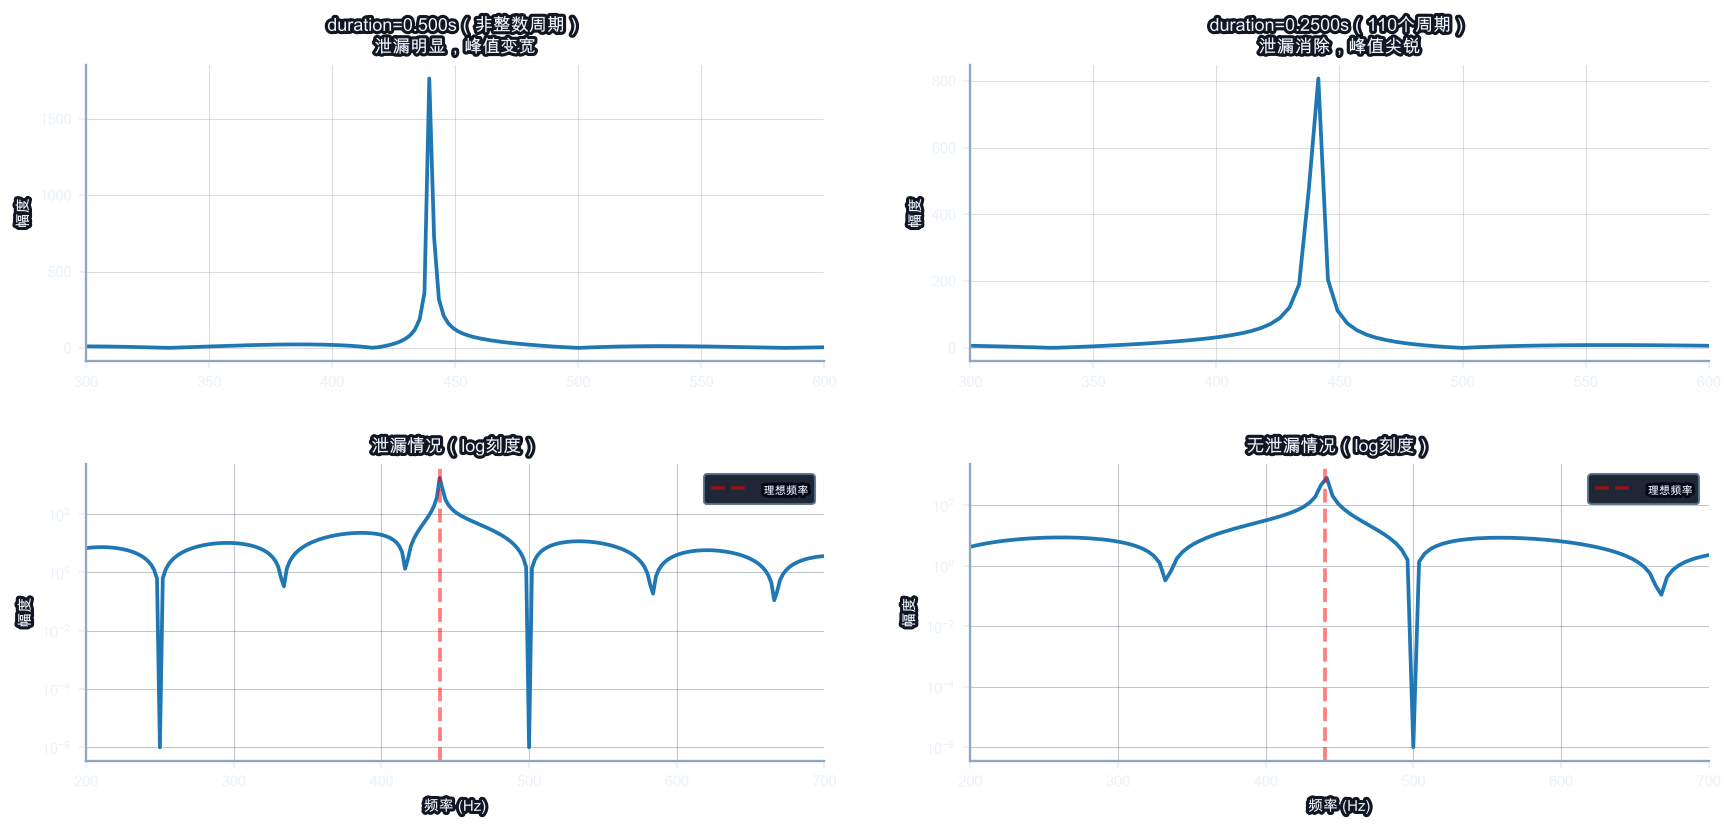

In [13]:
# 谱泄漏对比：有/无整数周期的信号
sr = 8000
freq = 440

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# 情形1：duration 不是整数周期 → 泄漏严重
duration_leak = 0.5
n_samples_leak = int(sr * duration_leak)
t = np.arange(n_samples_leak) / sr
x_leak = np.sin(2 * np.pi * freq * t)
N_fft = next_power_of_two(n_samples_leak)
x_padded = np.zeros(N_fft)
x_padded[:n_samples_leak] = x_leak
X_leak = np.fft.fft(x_padded)
freqs = np.arange(N_fft // 2 + 1) * sr / N_fft
amp_leak = np.abs(X_leak[:N_fft // 2 + 1])

axes[0, 0].plot(freqs, amp_leak)
axes[0, 0].set_xlim(300, 600)
axes[0, 0].set_title(f'duration={duration_leak:.3f}s（非整数周期）\n泄漏明显，峰值变宽')
axes[0, 0].set_ylabel('幅度')

# 情形2：调整为整数周期 → 泄漏消除
# 对 440 Hz，1/440 ≈ 0.00227 秒是一个周期
# 取 N_periods=110，总时长 = 110/440 = 0.25 秒（2的倍数周期）
n_periods = 110
duration_clean = n_periods / freq
n_samples_clean = int(sr * duration_clean)
t_clean = np.arange(n_samples_clean) / sr
x_clean = np.sin(2 * np.pi * freq * t_clean)
N_fft_clean = next_power_of_two(n_samples_clean)
x_padded_clean = np.zeros(N_fft_clean)
x_padded_clean[:n_samples_clean] = x_clean
X_clean = np.fft.fft(x_padded_clean)
freqs_clean = np.arange(N_fft_clean // 2 + 1) * sr / N_fft_clean
amp_clean = np.abs(X_clean[:N_fft_clean // 2 + 1])

axes[0, 1].plot(freqs_clean, amp_clean)
axes[0, 1].set_xlim(300, 600)
axes[0, 1].set_title(f'duration={duration_clean:.4f}s（{n_periods}个周期）\n泄漏消除，峰值尖锐')
axes[0, 1].set_ylabel('幅度')

# 放大对比：泄漏情况下的旁瓣
axes[1, 0].semilogy(freqs, np.maximum(amp_leak, 1e-6))
axes[1, 0].set_xlim(200, 700)
axes[1, 0].axvline(440, color='r', linestyle='--', alpha=0.5, label='理想频率')
axes[1, 0].set_title('泄漏情况（log刻度）')
axes[1, 0].set_xlabel('频率 (Hz)')
axes[1, 0].set_ylabel('幅度')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# 无泄漏情况对比
axes[1, 1].semilogy(freqs_clean, np.maximum(amp_clean, 1e-6))
axes[1, 1].set_xlim(200, 700)
axes[1, 1].axvline(440, color='r', linestyle='--', alpha=0.5, label='理想频率')
axes[1, 1].set_title('无泄漏情况（log刻度）')
axes[1, 1].set_xlabel('频率 (Hz)')
axes[1, 1].set_ylabel('幅度')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("谱泄漏对比总结：")
print("="*60)
print(f"有泄漏（duration={duration_leak:.3f}s）：")
print(f"  - 峰值周围有明显的旁瓣（side lobes）")
print(f"  - 能量分散在多个bin里")
print(f"\n无泄漏（duration={duration_clean:.4f}s，{n_periods}周期）：")
print(f"  - 几乎所有能量集中在一个bin")
print(f"  - 旁瓣降到噪声层")
print("\n💡 实务建议：")
print("   1. 如果知道信号频率，选择整数周期的时长")
print("   2. 或者在下一课（L41）学习加窗，自动抑制旁瓣")

## 本课收束

`frequency_bins(N, sr)` 把 FFT 的 bin 下标翻译成 Hz，输出 shape `(N//2+1,)` 的单边频率轴，最后一个点正好落在奈奎斯特频率 `sr/2` 上。
这条轴会直接被 `aurora.audio.stft.magnitude_spectrogram()` 拿去标每一帧的频率坐标，所以你在这里写的，其实就是 STFT 的坐标层。
幅度谱、功率谱、dB 谱分别适合不同的后续处理，音频特征提取里最常见的还是 dB 谱。
下一课（L41）会把 Hann/Hamming 窗叠到这条频谱管线上，完整跑通「分帧→加窗→FFT」。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：频谱分析手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：`sr=8000, N=256`
- Δf = sr/N = ?（Hz/bin）
- 440 Hz 落在第几号 bin？（k = round(440/Δf)）
- 该 bin 对应的精确频率是多少 Hz？

**问 2**：`frequency_bins(8, 8000)` 应返回哪 5 个频率值？  
（形状：(N//2+1,) = (5,)，从 0 到 Nyquist=4000 Hz）

**问 3**：要将 10 Hz 的两个音符区分开，FFT 点数 N 最少需要多少？  
（要求 Δf = sr/N ≤ 10 Hz，sr=16000）  
**澄清**："区分开"的含义是两个频率峰的最小距离 ≥ Δf，即两个峰至少不能在同一个 bin 里。

**问 4**：幅度谱 vs 功率谱的关系是什么？  
（提示：功率谱 = 幅度谱²）

**问 5**：为什么频率轴只取 `k=0..N//2`（单边谱），而不是 `k=0..N-1`？

**问 6（进阶）**：在问 3 中，理论最小 N=1600（使 Δf=10 Hz）。但代码实际取 N=2048。为什么？  
**背景**：FFT（Fast Fourier Transform）要求 N 是 2 的幂；DFT（Discrete Fourier Transform）没有这个限制。  
**答案**：L39 实现的是 Cooley-Tukey FFT（只支持 2 的幂），所以必须向上取 2 的幂 → $N = 2^{\lceil \log_2(1600) \rceil} = 2048$。  
如果改用标准 DFT（numpy.fft.fft 自动选择），N=1600 也行。

推导完成后运行下面格对答案。

In [14]:
# ✏️ 对答案格
import numpy as np

# 问1：sr=8000, N=256
sr, N = 8000, 256
delta_f = sr / N
assert delta_f == 31.25
k_440 = round(440 / delta_f)
f_k440 = k_440 * delta_f
assert k_440 == 14
assert f_k440 == 437.5
print(f"Q1 ✅  Δf={delta_f} Hz/bin，440Hz→第{k_440}号bin，精确频率={f_k440} Hz")

# 问2：frequency_bins(8, 8000) = [0, 1000, 2000, 3000, 4000]
expected_bins = np.array([0.0, 1000.0, 2000.0, 3000.0, 4000.0])
try:
    result = frequency_bins(8, 8000)
    assert result.shape == (5,), f"shape 应=(5,)，得到 {result.shape}"
    assert np.allclose(result, expected_bins, atol=1e-10)
    print(f"Q2 ✅  frequency_bins(8, 8000)={result}")
except (NotImplementedError, TypeError):
    print("⬜ Q2：请先实现 frequency_bins()，再运行对答案格")

# 问3：最小 N for Δf≤10 Hz
sr2 = 16000
min_N = int(np.ceil(sr2 / 10))
# 需向上取2的幂（Cooley-Tukey要求）
N_pow2 = 2 ** int(np.ceil(np.log2(min_N)))
assert min_N == 1600
print(f"Q3 ✅  理论最小 N={min_N}（Δf={sr2/min_N} Hz），")
print(f'     "区分开"= 两个频率峰分别落在不同的bin里（bin距离 ≥ Δf）')
print(f"     取2的幂则 N={N_pow2}")

# 问4：幅度谱 vs 功率谱
X = np.fft.rfft(np.array([1.0, 0.0, -1.0, 0.0]))
mag = np.abs(X)
power = mag ** 2
assert np.allclose(power, mag**2, atol=1e-15)
print(f"Q4 ✅  幅度谱={np.round(mag,4)}，功率谱=幅度谱²={np.round(power,4)}")

# 问5：单边谱 — 实信号共轭对称
x_real = np.random.randn(8)
X_full = np.fft.fft(x_real)
# 验证 X[N-k] = conj(X[k])
for k_val in range(1, 4):
    assert np.isclose(X_full[8-k_val], np.conj(X_full[k_val]), atol=1e-10)
print(f"Q5 ✅  实信号满足 X[N-k]=X[k]*（共轭对称），后半段无新信息，只取 k=0..N/2")

# 问6：FFT vs DFT
print(f"\nQ6 ✅  FFT vs DFT 的区别：")
print(f"     - FFT（快速傅里叶变换，Cooley-Tukey）：必须 N = 2^k，快速 O(N log N)")
print(f"     - DFT（离散傅里叶变换）：任意 N 都行，更慢 O(N²)")
print(f"     - L39 实现的 aurora.audio.transforms.fft 是 Cooley-Tukey，所以必须补零到2的幂")
print(f"     - 若改用 numpy.fft.fft（已优化的混合算法），N=1600 也可直接计算，无需补零")

print("\n🎉 频谱分析白板挑战通过！frequency_bins(N,sr)=k*sr/N，k=0..N//2。")

Q1 ✅  Δf=31.25 Hz/bin，440Hz→第14号bin，精确频率=437.5 Hz
⬜ Q2：请先实现 frequency_bins()，再运行对答案格
Q3 ✅  理论最小 N=1600（Δf=10.0 Hz），
     "区分开"= 两个频率峰分别落在不同的bin里（bin距离 ≥ Δf）
     取2的幂则 N=2048
Q4 ✅  幅度谱=[0. 2. 0.]，功率谱=幅度谱²=[0. 4. 0.]
Q5 ✅  实信号满足 X[N-k]=X[k]*（共轭对称），后半段无新信息，只取 k=0..N/2

Q6 ✅  FFT vs DFT 的区别：
     - FFT（快速傅里叶变换，Cooley-Tukey）：必须 N = 2^k，快速 O(N log N)
     - DFT（离散傅里叶变换）：任意 N 都行，更慢 O(N²)
     - L39 实现的 aurora.audio.transforms.fft 是 Cooley-Tukey，所以必须补零到2的幂
     - 若改用 numpy.fft.fft（已优化的混合算法），N=1600 也可直接计算，无需补零

🎉 频谱分析白板挑战通过！frequency_bins(N,sr)=k*sr/N，k=0..N//2。


In [ ]:
# ✏️ 本课自评
l40_review = {
    "frequency_resolution":    None,  # 记住 Δf=sr/N（Hz/bin）？True/False
    "frequency_bins_impl":     None,  # frequency_bins 实现并通过断言？True/False
    "magnitude_vs_power":      None,  # 理解幅度谱=|X[k]|，功率谱=|X[k]|²？True/False
    "one_sided_spectrum":      None,  # 理解实信号只需单边谱（共轭对称）？True/False
    "whiteboard_passed":       None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l40_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l40_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L40 全部通关！进入 L41：加窗 FFT 完整流程')

---

→ **下一课**　[L41 · 加窗 FFT 完整流程](L41_fft_full.ipynb)

> 下节课将学习 **加窗 FFT 完整流程**：信号 → 加窗 → FFT → 幅度谱，一条管线跑通。